# Etapa 1 — Base Kaggle e EDA

Importação da base [Bank Marketing (Kaggle, henriqueyamahata)](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data) via `kagglehub` e criação do dataset em `pandas`.

Nesta etapa: só download + carga. Análise exploratória segue em células futuras.

In [1]:
import os

import kagglehub
import pandas as pd

In [2]:
# Download latest version
path = kagglehub.dataset_download(
    "henriqueyamahata/bank-marketing",
    output_dir="../data/raw",
    force_download=True,
)

print("Path to dataset files:", path)

  0%|          | 0.00/393k [00:00<?, ?B/s]

100%|██████████| 393k/393k [00:00<00:00, 696kB/s]

100%|██████████| 393k/393k [00:00<00:00, 693kB/s]

Extracting files...


Path to dataset files: ../data/raw


In [3]:
csv_path = None
for root, _, files in os.walk(path):
    if "bank-additional-full.csv" in files:
        csv_path = os.path.join(root, "bank-additional-full.csv")
        break

csv_path

'../data/raw/bank-additional-full.csv'

In [4]:
df = pd.read_csv(csv_path, sep=";")
df.shape

(41188, 21)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Passo 1 — Estrutura

Abaixo analisamos tipos de dado (dtype) e forma de cada coluna, checamos nulos explícitos e cardinalidade (`nunique`). Serve pra decidir nível de mensuração de cada variável e candidatos a braço/contexto do bandit.

Abaixo analisamos dtype de cada coluna (`df.info()`) — base pra escolher estatística descritiva e encoding válidos.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Abaixo analisamos nulos explícitos (`df.isnull().sum()`) — testa se ausência foi codificada como `NaN`. Hipótese: este dataset marca ausência como string `"unknown"`, não `NaN` — a confirmar no passo 3.

In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Abaixo analisamos cardinalidade por coluna (`df.nunique()`) — colunas com poucas categorias estáveis são candidatas a braço do bandit (ex. `contact`); colunas quase-constantes (`nunique()==1`) não carregam informação.

In [8]:
df.nunique().sort_values()

contact              2
y                    2
default              3
loan                 3
poutcome             3
housing              3
marital              4
day_of_week          5
previous             8
education            8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

## Passo 2 — Distribuição do target `y`

`y` é variável Bernoulli ($Y_i \sim \text{Bernoulli}(p)$). Estimamos $\hat{p} = \bar{y}$ (taxa de conversão) e checamos desbalanceamento — decide se acurácia é métrica válida e quanto desbalanceado é o "sucesso" pra simulação do bandit (Etapa 3).

Abaixo analisamos contagem bruta por classe (`df["y"].value_counts()`) — confirma tamanho de amostra de cada classe.

In [9]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

Abaixo analisamos proporção por classe (`df["y"].value_counts(normalize=True)`) — é o estimador $\hat{p}$ da taxa de conversão populacional.

In [10]:
df["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

## Passo 3 — `"unknown"` por coluna

Ausência aqui não é `NaN`, é a string `"unknown"`. Contamos quanto e onde ocorre pra decidir tratamento: manter como categoria própria (se proporção relevante, pode ser sinal MAR/MNAR — Rubin, 1976) ou dropar linha (se marginal).

Abaixo analisamos contagem bruta de `"unknown"` por coluna categórica, ordenado decrescente.

In [11]:
df.select_dtypes(include="object").eq("unknown").sum().sort_values(ascending=False)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

Abaixo analisamos proporção (%) de `"unknown"` por coluna — decide se é marginal (dropar linha) ou relevante (manter como categoria).

In [12]:
unknown_pct = df.select_dtypes(include="object").eq("unknown").mean() * 100
unknown_pct.round(2).sort_values(ascending=False)

default        20.87
education       4.20
housing         2.40
loan            2.40
job             0.80
marital         0.19
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64

## Passo 4 — Numéricas (describe + sentinel `pdays`)

`describe()` dá posição/dispersão, só interpretável sem *sentinel value*. `pdays=999` é flag "nunca contatado antes" disfarçada de número — distorce média/quartil se não isolada.

Abaixo analisamos estatística descritiva bruta de todas colunas numéricas (`df.describe()`) — observe `pdays`, quartil vai parecer estranho por causa do sentinel.

In [13]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Abaixo analisamos proporção de sentinel em `pdays` (`(df["pdays"] == 999).mean()`) — quantifica quanto a média/quartil bruto acima estava distorcido.

In [14]:
(df["pdays"] == 999).mean() * 100

np.float64(96.32174419733903)

## Passo 5 — Categóricas + crosstab `contact` × `y`

Distribuição de frequência por categoria é descritiva; cruzar com `y` estima taxa de conversão condicional por grupo — testa se `contact` como braço tem sinal (taxas diferentes) ou é ruído. **Cautela:** associação observacional, não causal — alocação histórica de canal não foi aleatória.

Abaixo analisamos frequência de categorias relevantes pro contexto/braço (`contact`, `poutcome`, `month`, `job`, `education`, `marital`).

In [15]:
for col in ["contact", "poutcome", "month", "job", "education", "marital"]:
    print(df[col].value_counts(), "\n")

contact
cellular     26144
telephone    15044
Name: count, dtype: int64 

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64 

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64 

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64 

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64 

marital
married     24928
single      11568
divorced     4612
unknown        80
Name

Abaixo analisamos taxa de conversão condicional por canal (`contact` × `y`) — insumo direto pro baseline "melhor canal histórico" e teste de sinal do braço.

In [16]:
df.groupby("contact")["y"].value_counts(normalize=True).unstack()

y,no,yes
contact,,
cellular,0.852624,0.147376
telephone,0.947687,0.052313


Abaixo analisamos taxa de conversão condicional por resultado de campanha anterior (`poutcome` × `y`) — única categórica com semântica causal-adjacente no dataset.

In [17]:
df.groupby("poutcome")["y"].value_counts(normalize=True).unstack()

y,no,yes
poutcome,,
failure,0.857714,0.142286
nonexistent,0.911678,0.088322
success,0.348871,0.651129


## Passo 6 — Confundidor temporal em `contact`

Gap de conversão `cellular` vs `telephone` pode ser Simpson's paradox: campanha rodou 2008-2010 (crise no meio), `month`/indicadores macro capturam regime econômico. Se `contact` correlaciona com período, gap pode ser regime, não canal. Checagem exploratória, não inferência causal completa (fora de escopo Etapa 1).

Abaixo analisamos distribuição de `month` por canal (`contact`), normalizado por coluna — se canais concentram em meses/períodos diferentes, é sinal de confundidor temporal.

In [18]:
pd.crosstab(df["month"], df["contact"], normalize="columns")

contact,cellular,telephone
month,,
apr,0.093521,0.012430
aug,0.226017,0.017881
dec,0.005699,0.002194
jul,0.233170,0.071656
jun,0.031365,0.298990
mar,0.018589,0.003988
may,0.211062,0.548458
nov,0.140606,0.028250
oct,0.021535,0.010303


Abaixo analisamos média de indicadores macroeconômicos por canal — proxy de regime econômico predominante em cada canal.

In [19]:
df.groupby("contact")[["emp.var.rate", "euribor3m", "nr.employed"]].mean()

,emp.var.rate,euribor3m,nr.employed
contact,,,
cellular,-0.387137,3.095316,5152.284260
telephone,0.896969,4.535349,5192.671856


## Passo 7 — Visualizações

Gráfico reforça achado já defendido só com número — leitura mais rápida pra relatório/pitch (Etapa 8). Paleta categórica fixa do projeto: slot 1 azul `#2a78d6`, slot 2 laranja `#eb6834` (ordem já validada CVD-safe); heatmap usa par divergente azul↔vermelho com ponto neutro cinza no zero.

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"
COLOR_TEXT = "#0b0b0b"
COLOR_SURFACE = "#fcfcfb"

plt.rcParams.update(
    {
        "axes.edgecolor": COLOR_MUTED,
        "axes.labelcolor": COLOR_TEXT,
        "text.color": COLOR_TEXT,
        "xtick.color": COLOR_MUTED,
        "ytick.color": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": COLOR_SURFACE,
        "axes.facecolor": COLOR_SURFACE,
    }
)

Abaixo visualizamos a contagem de `y` — leitura visual do desbalanceamento já quantificado no passo 2 (`p̂ = 0.1127`).

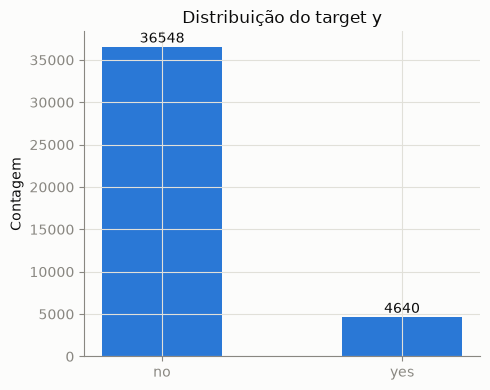

In [21]:
counts = df["y"].value_counts()

plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index, counts.values, color=COLOR_BLUE, width=0.5)
for bar, v in zip(bars, counts.values):
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, v + 500, f"{v}", ha="center", color=COLOR_TEXT)
plt.title("Distribuição do target y")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

Abaixo visualizamos distribuição de `age` por classe de `y`, normalizada por densidade (não contagem bruta, já que as classes têm tamanhos muito diferentes — passo 2). Se as curvas divergem, `age` é candidata a contexto preditivo.

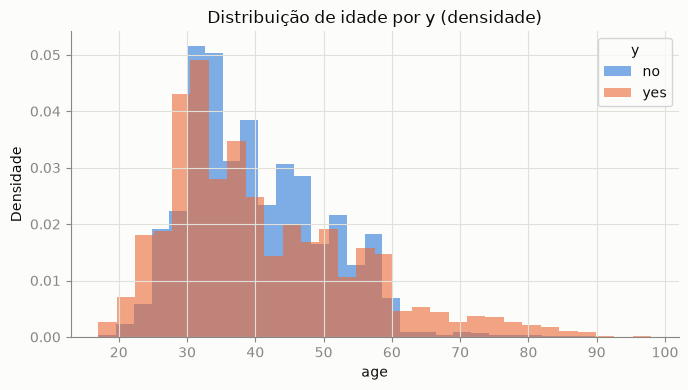

In [22]:
no_ages = df.loc[df["y"] == "no", "age"]
yes_ages = df.loc[df["y"] == "yes", "age"]

plt.figure(figsize=(7, 4))
plt.hist(no_ages, bins=30, density=True, alpha=0.6, label="no", color=COLOR_BLUE)
plt.hist(yes_ages, bins=30, density=True, alpha=0.6, label="yes", color=COLOR_ORANGE)
plt.title("Distribuição de idade por y (densidade)")
plt.xlabel("age")
plt.ylabel("Densidade")
plt.legend(title="y")
plt.tight_layout()
plt.show()

Abaixo visualizamos taxa de conversão por canal — leitura visual do gap achado no passo 5 (14.7% vs 5.2%), lembrando da cautela do passo 6 (confundido com regime econômico).

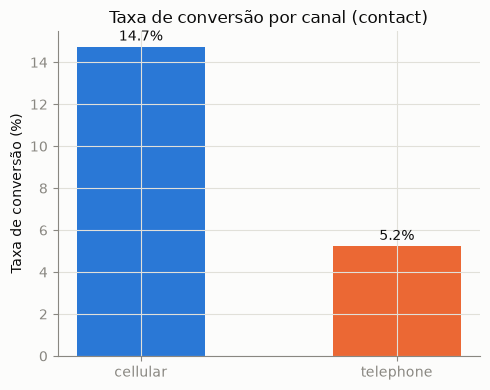

In [23]:
rates = df.groupby("contact")["y"].apply(lambda s: (s == "yes").mean()) * 100

plt.figure(figsize=(5, 4))
bars = plt.bar(rates.index, rates.values, color=[COLOR_BLUE, COLOR_ORANGE], width=0.5)
for bar, v in zip(bars, rates.values):
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, v + 0.3, f"{v:.1f}%", ha="center", color=COLOR_TEXT)
plt.title("Taxa de conversão por canal (contact)")
plt.ylabel("Taxa de conversão (%)")
plt.tight_layout()
plt.show()

Abaixo visualizamos contagem por mês e canal, em ordem cronológica — visual do confundidor temporal achado no passo 6 (telephone concentrado em mai/jun).

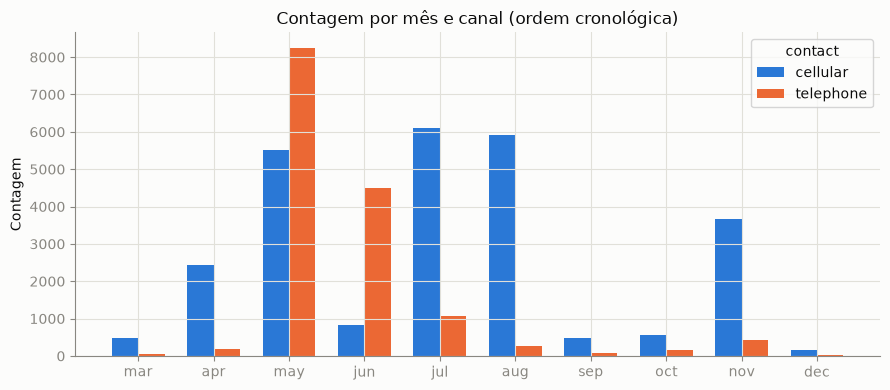

In [24]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
ct = pd.crosstab(df["month"], df["contact"]).reindex(month_order)

x = range(len(ct))
width = 0.35
off_cellular = [i - width / 2 for i in x]
off_telephone = [i + width / 2 for i in x]

plt.figure(figsize=(9, 4))
plt.bar(off_cellular, ct["cellular"], width, label="cellular", color=COLOR_BLUE)
plt.bar(off_telephone, ct["telephone"], width, label="telephone", color=COLOR_ORANGE)
plt.xticks(list(x), ct.index)
plt.title("Contagem por mês e canal (ordem cronológica)")
plt.ylabel("Contagem")
plt.legend(title="contact")
plt.tight_layout()
plt.show()

Abaixo visualizamos correlação entre variáveis numéricas (paleta divergente azul↔vermelho, ponto neutro cinza no zero) — checa multicolinearidade. Indicadores macro (`emp.var.rate`, `euribor3m`, `nr.employed`) são conhecidos por serem redundantes; feature duplicada não deveria entrar dobrada no contexto do bandit (Etapa 2/3).

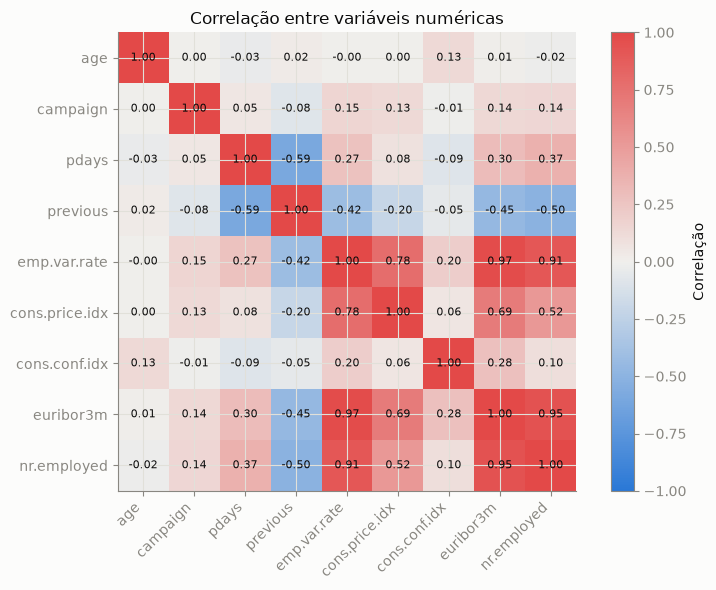

In [25]:
numeric_cols = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]
corr = df[numeric_cols].corr()

diverging_colors = ["#2a78d6", "#f0efec", "#e34948"]
diverging_cmap = LinearSegmentedColormap.from_list("diverging", diverging_colors)

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)
plt.colorbar(im, label="Correlação")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = f"{corr.iloc[i, j]:.2f}"
        plt.text(j, i, value, ha="center", va="center", fontsize=8, color=COLOR_TEXT)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

## Passo 8 — Tratamento final + persistência

Consolida as decisões já justificadas: `drop("duration")` (vazamento temporal, obrigatório), `foi_contatado_antes = (pdays != 999)` (desfaz sentinel do passo 4), `"unknown"` mantido como está (decisão do passo 3). Persiste em `data/processed/` (gitignorado) pra Etapa 2 reaproveitar sem reprocessar.

In [26]:
df_clean = df.drop(columns=["duration"])
df_clean["foi_contatado_antes"] = df_clean["pdays"] != 999
df_clean.shape

(41188, 21)

Abaixo persistimos `df_clean` em `data/processed/` — parquet (colunar, tipado, mais eficiente que CSV pra reuso em outras etapas).

In [27]:
df_clean.to_parquet("../data/processed/bank_marketing_clean.parquet", index=False)
print("Salvo em data/processed/bank_marketing_clean.parquet")

Salvo em data/processed/bank_marketing_clean.parquet
